**Description :** Insurance Chanres Prediction Model.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('insurance_data.csv')

In [5]:
df

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.210,0.0,no,29087.54313,17.0,715428.0,4.720921e+06,0.0,5.578497e+07,southeast,1121.87390
1,18.0,male,30.140,0.0,no,39053.67437,7.0,699157.0,4.329832e+06,0.0,1.370089e+07,southeast,1131.50660
2,18.0,male,33.330,0.0,no,39023.62759,19.0,702341.0,6.884861e+06,0.0,7.352311e+07,southeast,1135.94070
3,18.0,male,33.660,0.0,no,28185.39332,11.0,700250.0,4.274774e+06,0.0,7.581968e+07,southeast,1136.39940
4,18.0,male,34.100,0.0,no,14697.85941,16.0,711584.0,3.787294e+06,0.0,2.301232e+07,southeast,1137.01100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,33.0,female,35.530,0.0,yes,63142.25346,32.0,1091267.0,1.703805e+08,2.0,3.101107e+09,northwest,55135.40209
1334,31.0,female,38.095,1.0,yes,43419.95227,31.0,1107872.0,2.015152e+08,2.0,3.484216e+09,northeast,58571.07448
1335,52.0,male,34.485,3.0,yes,52458.92353,25.0,1092005.0,2.236450e+08,2.0,3.640807e+09,northwest,60021.39897
1336,45.0,male,30.360,0.0,yes,69927.51664,34.0,1106821.0,2.528924e+08,3.0,4.006359e+09,southeast,62592.87309


# EDA

Get basic info about the dataset. Check null values, duplicate value.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [7]:
df.isnull().sum()  # We will get the null values with respect to the columns


age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64

In [8]:
df.isnull().sum().sum()

np.int64(52)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [ ]:
# 52 null values

In [ ]:
# Let's replace null values

# Numerical column: Mean
# Categorical column: Mode

In [ ]:
# Approach : We need to go through each and every column of our dataset
# Then we need to check the data type of every column that we will be going through
# If the datatype of column == numerical (int,float) we will replace it with mean
# If the datatype of column == categorical we will replace with mode

In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')

In [12]:
df['smoker'].mode()[0]

'no'

In [13]:
for x in df.columns:
  if df[x].dtype=='object':
    df[x].fillna(df[x].mode()[0],inplace=True)
  else:
    df[x].fillna(df[x].mean(),inplace=True)

C:\Users\Hemant\AppData\Local\Temp\ipykernel_47816\3530114279.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[x].fillna(df[x].mean(),inplace=True)
C:\Users\Hemant\AppData\Local\Temp\ipykernel_47816\3530114279.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [14]:
df['region'].mode()

0    southeast
Name: region, dtype: object

In [19]:
df['region'].mode()[0]

'southeast'

In [ ]:
pd.Series([10])

0    10
dtype: int64

In [20]:
df.isnull().sum()

age                                0
sex                                0
bmi                                0
children                           0
smoker                             0
Claim_Amount                       0
past_consultations                 0
num_of_steps                       0
Hospital_expenditure               0
NUmber_of_past_hospitalizations    0
Anual_Salary                       0
region                             0
charges                            0
dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1338 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1338 non-null   float64
 3   children                         1338 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1338 non-null   float64
 6   past_consultations               1338 non-null   float64
 7   num_of_steps                     1338 non-null   float64
 8   Hospital_expenditure             1338 non-null   float64
 9   NUmber_of_past_hospitalizations  1338 non-null   float64
 10  Anual_Salary                     1338 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

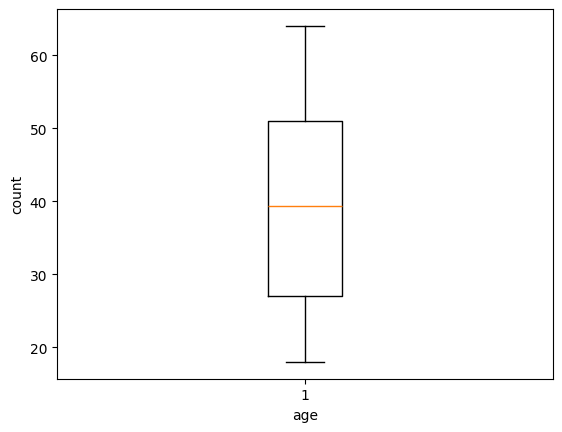

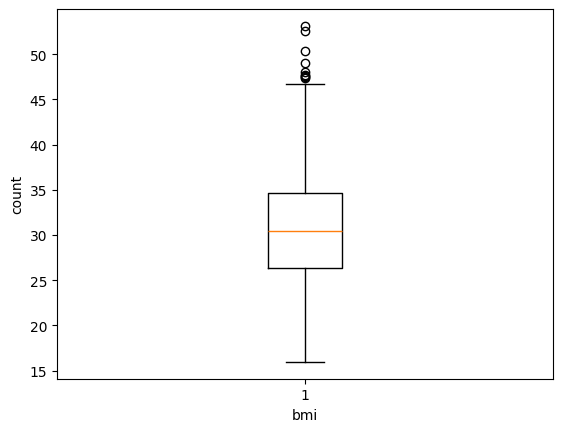

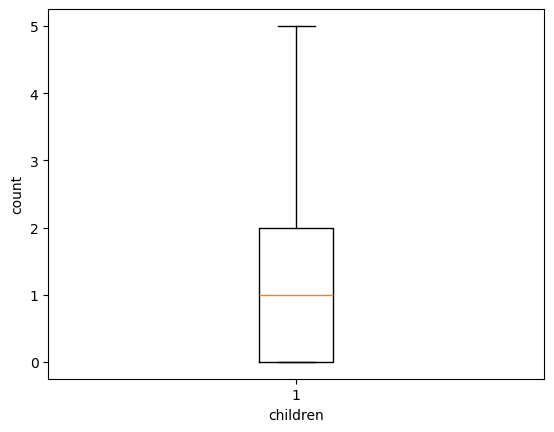

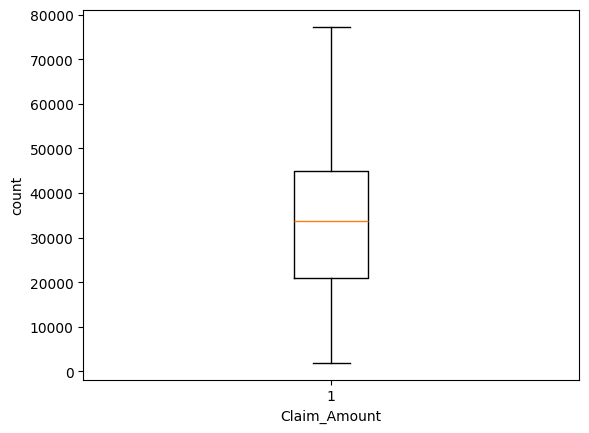

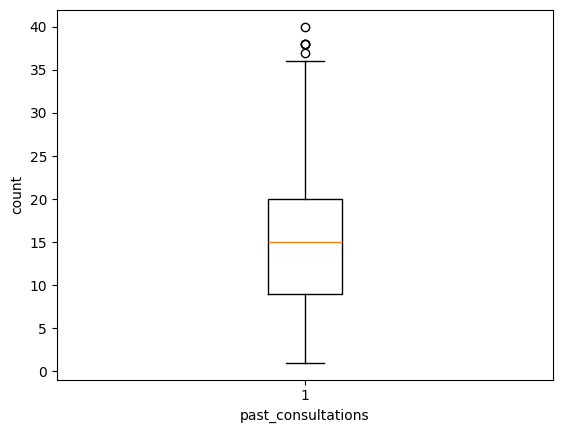

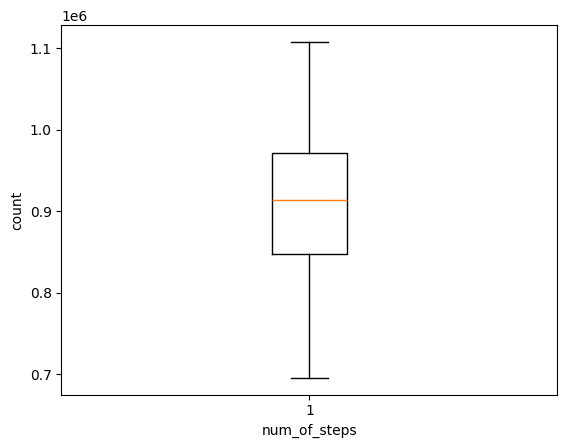

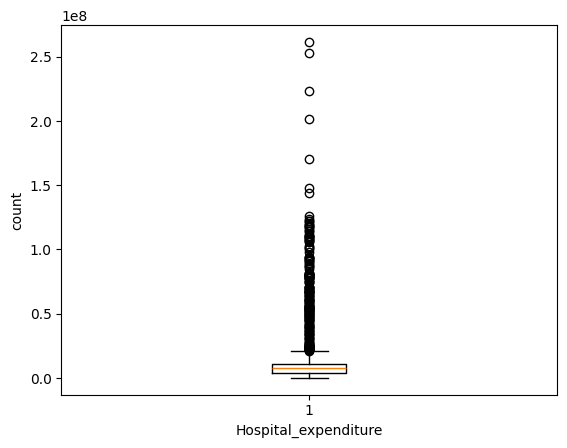

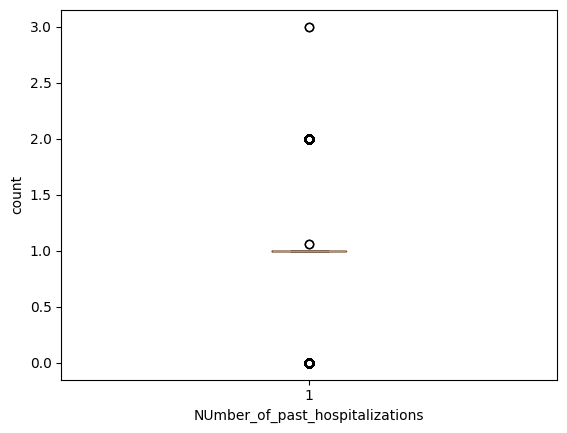

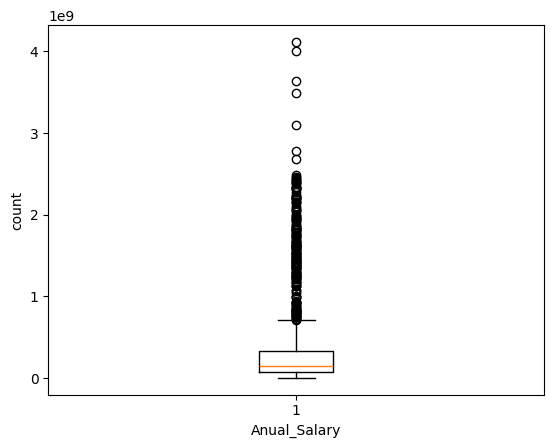

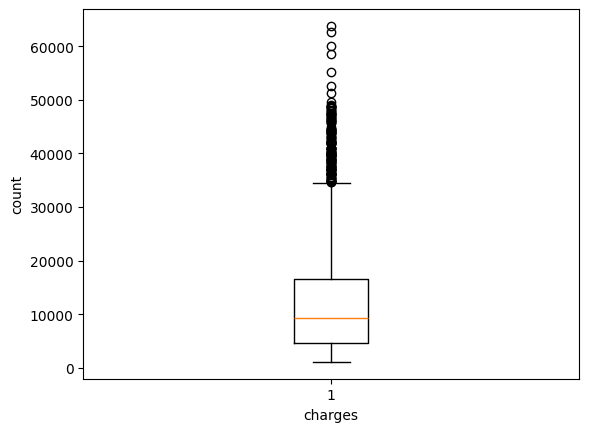

In [22]:
for x in df.columns:
  if df[x].dtype!='object':
    plt.boxplot(df[x])
    plt.xlabel(x)
    plt.ylabel('count')
    plt.show()

In [23]:
for x in df.columns:    # this wil loop through each column
  if df[x].dtype=='object' or x=='charges':
    continue    # it will skip the object column and charges as well because it is the target

  Q1 = df[x].quantile(0.25)
  Q3 = df[x].quantile(0.75)
  IQR = Q3-Q1
  lower_fence = Q1-1.5*IQR
  upper_fence = Q3+1.5*IQR
  df = df[(df[x]>=lower_fence) & (df[x]<=upper_fence)]  # if value is below lower fence of above upper fence is considered as outlier

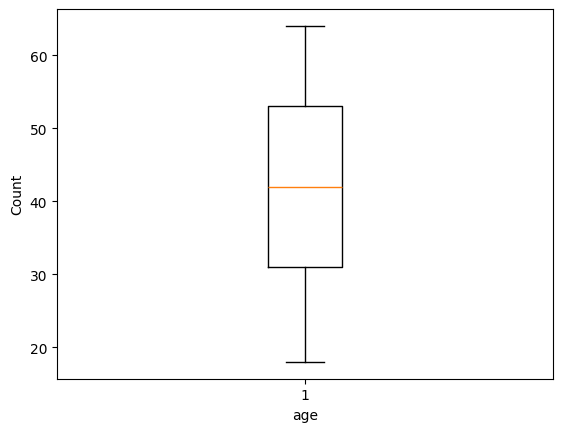

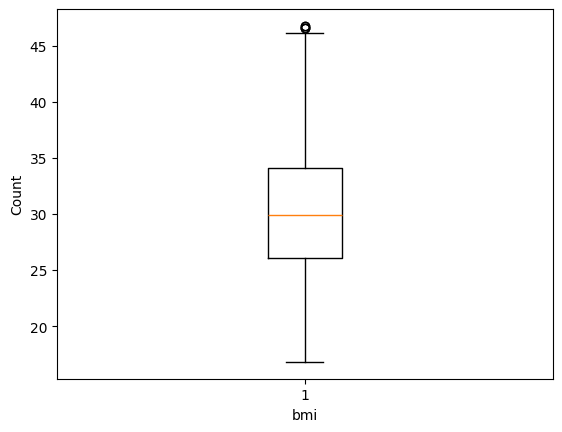

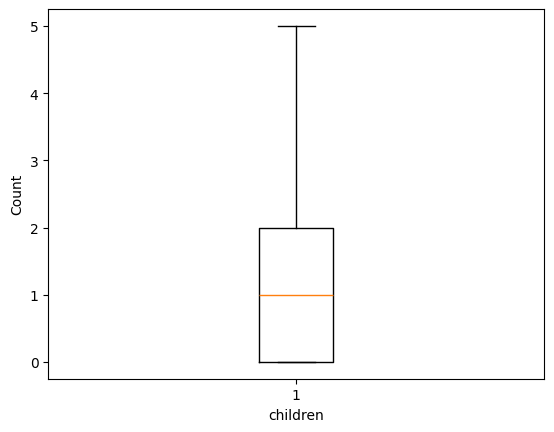

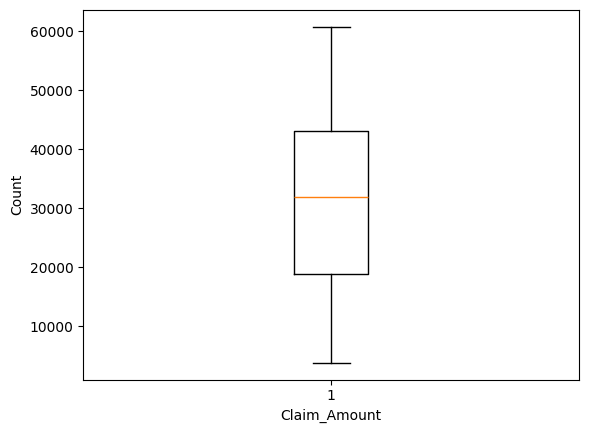

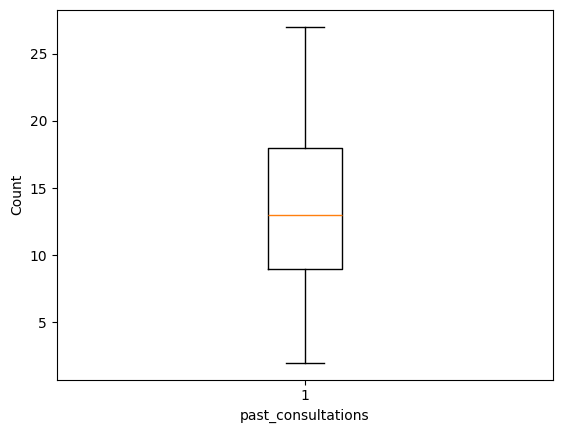

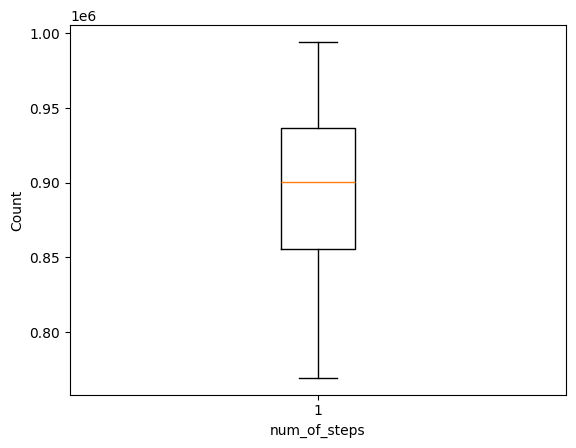

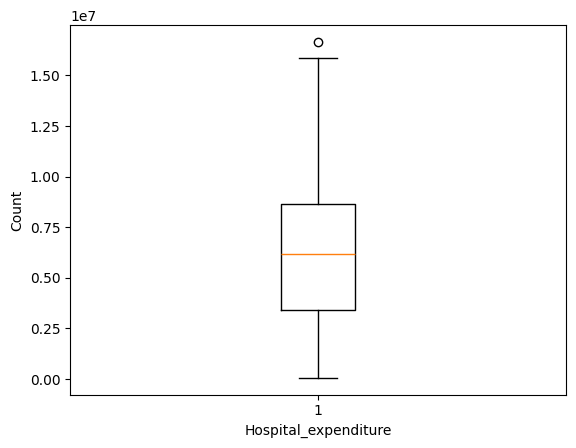

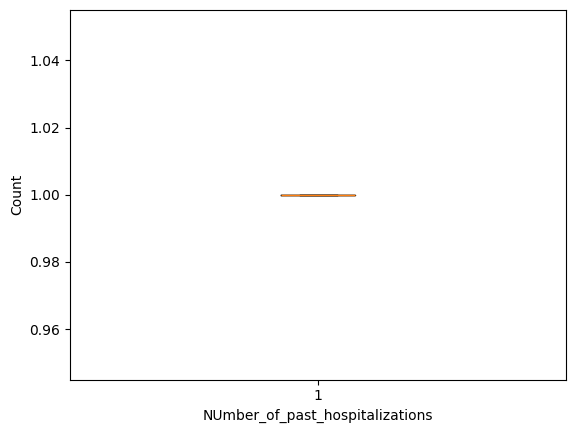

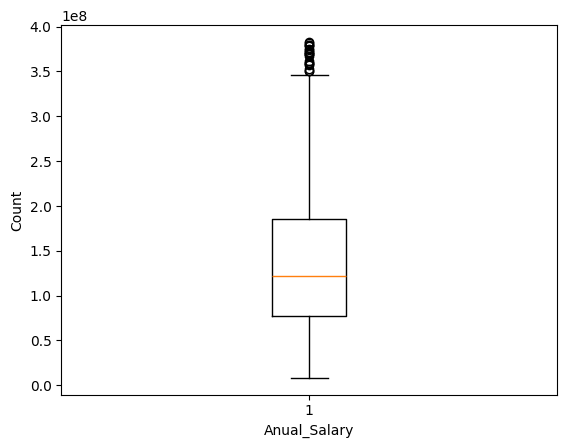

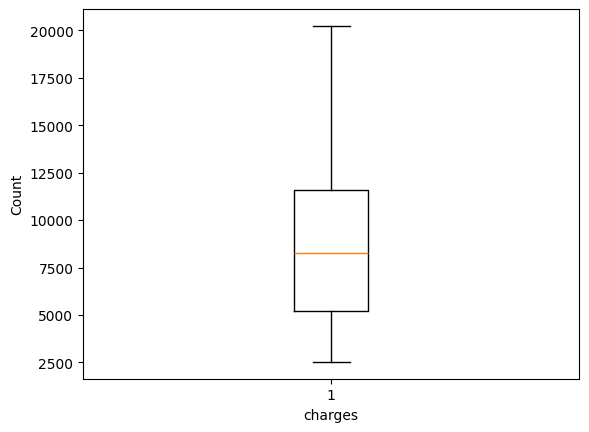

In [24]:
for x in df.columns:
  if df[x].dtype!='object':
    plt.boxplot(df[x])
    plt.xlabel(x)
    plt.ylabel('Count')
    plt.show()

In [ ]:
df

In [ ]:
# Feature selection

# VIF : Variance inflation factor
# VIF helps us to detect the multicolinearity among the columns.
# If your vif>=6 it means that column is not important for us, as it having high multicolinearity. We will remove those


In [25]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

In [26]:
col_list    # all independent numerical columns

['age',
 'bmi',
 'children',
 'Claim_Amount',
 'past_consultations',
 'num_of_steps',
 'Hospital_expenditure',
 'NUmber_of_past_hospitalizations',
 'Anual_Salary']

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [30]:
dummy = df[col_list]
dummy

,age,bmi,children,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary
151,25.0,27.550,0.0,39148.95495,10.0,780652.0,8.614147e+06,1.0,5.452601e+07
152,22.0,20.235,0.0,41547.52536,13.0,802627.0,2.491594e+05,1.0,1.671847e+07
153,25.0,35.625,0.0,39660.60193,12.0,770773.0,3.043323e+06,1.0,4.852694e+07
154,20.0,31.130,2.0,16032.87148,7.0,769255.0,1.599069e+06,1.0,2.441262e+07
155,21.0,17.400,1.0,31090.98977,21.0,778769.0,3.015365e+06,1.0,5.853579e+07
...,...,...,...,...,...,...,...,...,...
1046,29.0,27.940,1.0,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08
1048,31.0,25.900,3.0,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08
1050,31.0,29.810,0.0,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08
1062,43.0,20.045,2.0,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08


In [31]:
pd.DataFrame(dummy.values)

,0,1,2,3,4,5,6,7,8
0,25.0,27.550,0.0,39148.95495,10.0,780652.0,8.614147e+06,1.0,5.452601e+07
1,22.0,20.235,0.0,41547.52536,13.0,802627.0,2.491594e+05,1.0,1.671847e+07
2,25.0,35.625,0.0,39660.60193,12.0,770773.0,3.043323e+06,1.0,4.852694e+07
3,20.0,31.130,2.0,16032.87148,7.0,769255.0,1.599069e+06,1.0,2.441262e+07
4,21.0,17.400,1.0,31090.98977,21.0,778769.0,3.015365e+06,1.0,5.853579e+07
...,...,...,...,...,...,...,...,...,...
876,29.0,27.940,1.0,51168.25474,23.0,993751.0,1.665982e+07,1.0,3.712188e+08
877,31.0,25.900,3.0,46619.40230,27.0,989387.0,1.361938e+07,1.0,3.812895e+08
878,31.0,29.810,0.0,24382.58056,21.0,973924.0,1.028991e+07,1.0,3.745310e+08
879,43.0,20.045,2.0,21596.43846,10.0,994419.0,1.083030e+07,1.0,3.696849e+08


In [ ]:
vif_data = pd.DataFrame()
vif_data['Feature'] = dummy.columns   # In this feature column we are having all the independent numerical columns of our actual dataframe
vif_data
vif_list = []

for i in range (len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)  # i will be the column index
  vif_list.append(vif)
vif_data['VIF'] = vif_list

In [ ]:
vif_data

In [ ]:
df = df.drop(['NUmber_of_past_hospitalizations'],axis=1)

In [ ]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

dummy = df[col_list]
vif_data= pd.DataFrame()
vif_data['Feature']= col_list
vif_data
vif_list = []
for i in range(len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)
  vif_list.append(vif)
vif_data['VIF']= vif_list

In [ ]:
vif_data

In [ ]:
df = df.drop(columns=['num_of_steps'])

In [ ]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

dummy = df[col_list]
vif_data= pd.DataFrame()
vif_data['Feature']= col_list
vif_data
vif_list = []
for i in range(len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)
  vif_list.append(vif)
vif_data['VIF']= vif_list

In [ ]:
vif_data

In [ ]:
df = df.drop(columns=['bmi'])

In [ ]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

dummy = df[col_list]
vif_data= pd.DataFrame()
vif_data['Feature']= col_list
vif_data
vif_list = []
for i in range(len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)
  vif_list.append(vif)
vif_data['VIF']= vif_list

In [ ]:
vif_data

In [ ]:
df = df.drop(columns=['age'])

In [ ]:
col_list = []
for x in df.columns:
  if df[x].dtype!='object' and x!='charges':
    col_list.append(x)

dummy = df[col_list]
vif_data= pd.DataFrame()
vif_data['Feature']= col_list
vif_data
vif_list = []
for i in range(len(dummy.columns)):
  vif = variance_inflation_factor(dummy.values,i)
  vif_list.append(vif)
vif_data['VIF']= vif_list

In [ ]:
vif_data

In [ ]:
df

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [ ]:
for x in df.columns:
  if df[x].dtype=='object':
    df[x]=le.fit_transform(df[x])

In [ ]:
df

In [ ]:
X = df.iloc[:,:8]  #independent variable
y = df.iloc[:,-1]  #dependent variable

In [ ]:
X

In [ ]:
y

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=7)

In [ ]:
x_train

In [ ]:
y_train.shape

In [ ]:
x_test.shape

In [ ]:
y_test.shape

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

In [ ]:
error = pd.DataFrame(columns=['Actual values','Predicted values'])

In [ ]:
error

In [ ]:
error['Actual values']= y_test
error['Predicted values']=y_pred
error

In [ ]:
error['Error rate'] = error['Actual values'] - error['Predicted values']


In [ ]:
error

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
mse = mean_squared_error(y_test,y_pred)

In [ ]:
print(mse)

In [ ]:
rmse = np.sqrt(mse)

In [ ]:
rmse

In [ ]:
r2_accuracy = r2_score(y_test,y_pred)
r2_accuracy*100

In [ ]:
# regression plot

sns.regplot(x=y_pred,y=y_test,line_kws={'color':'red'},color='blue')
plt.xlabel('Prediction')
plt.ylabel('Actual values')
plt.title('Regression plot')
plt.show()